Dataset path: /kaggle/input/datasets/imbikramsaha/caltech-101/caltech-101
Found 102 classes
Total images: 9144

Generating Figure 3.3: caltech101_sample_images...
  Saved: caltech101_sample_images.png


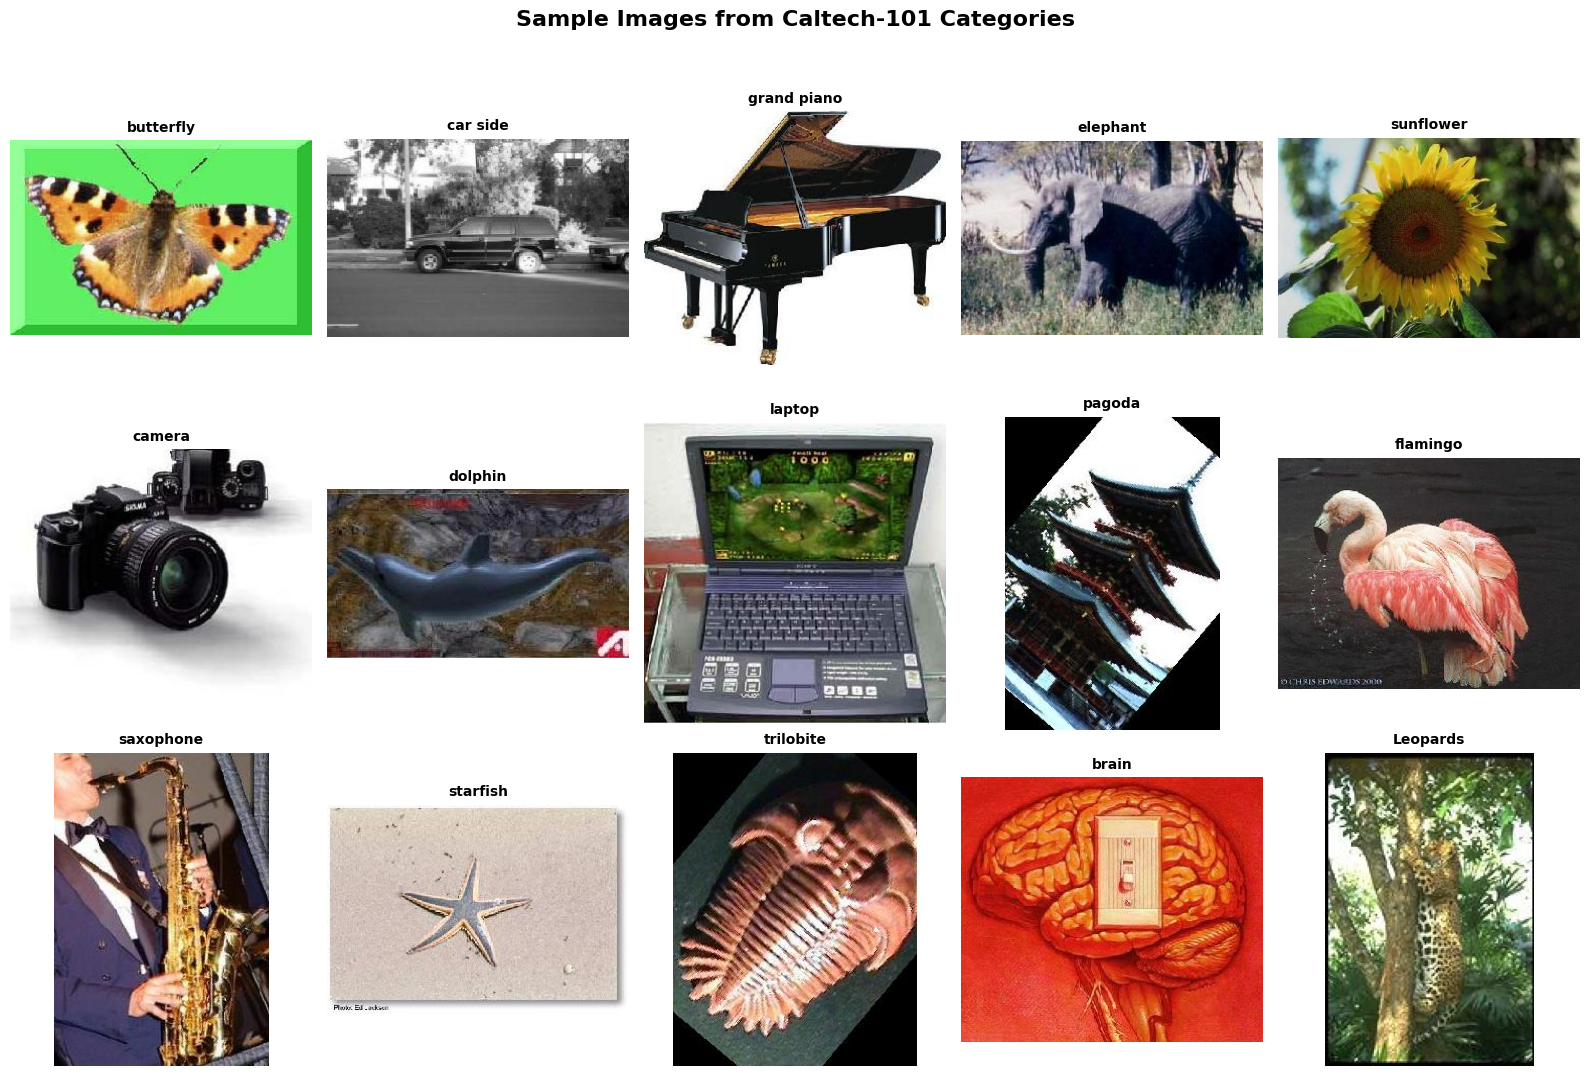


Generating Figure 3.4: caltech101_class_distribution...
  Saved: caltech101_class_distribution.png


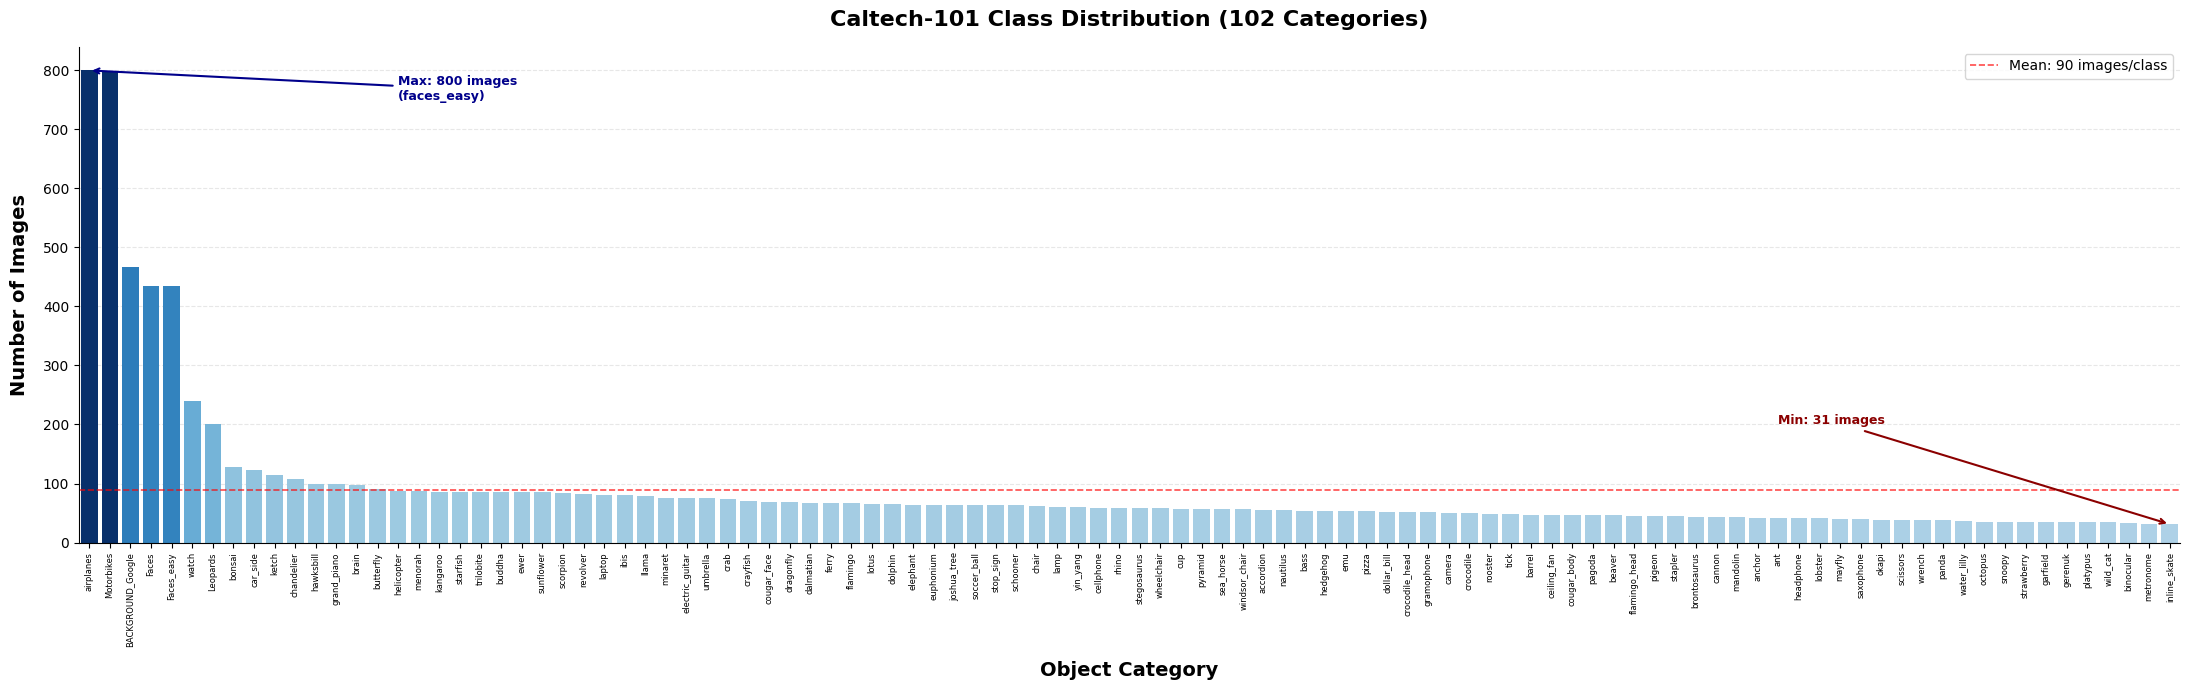


Generating Figure 3.5: caltech101_image_size_variation...
  Saved: caltech101_image_size_variation.png


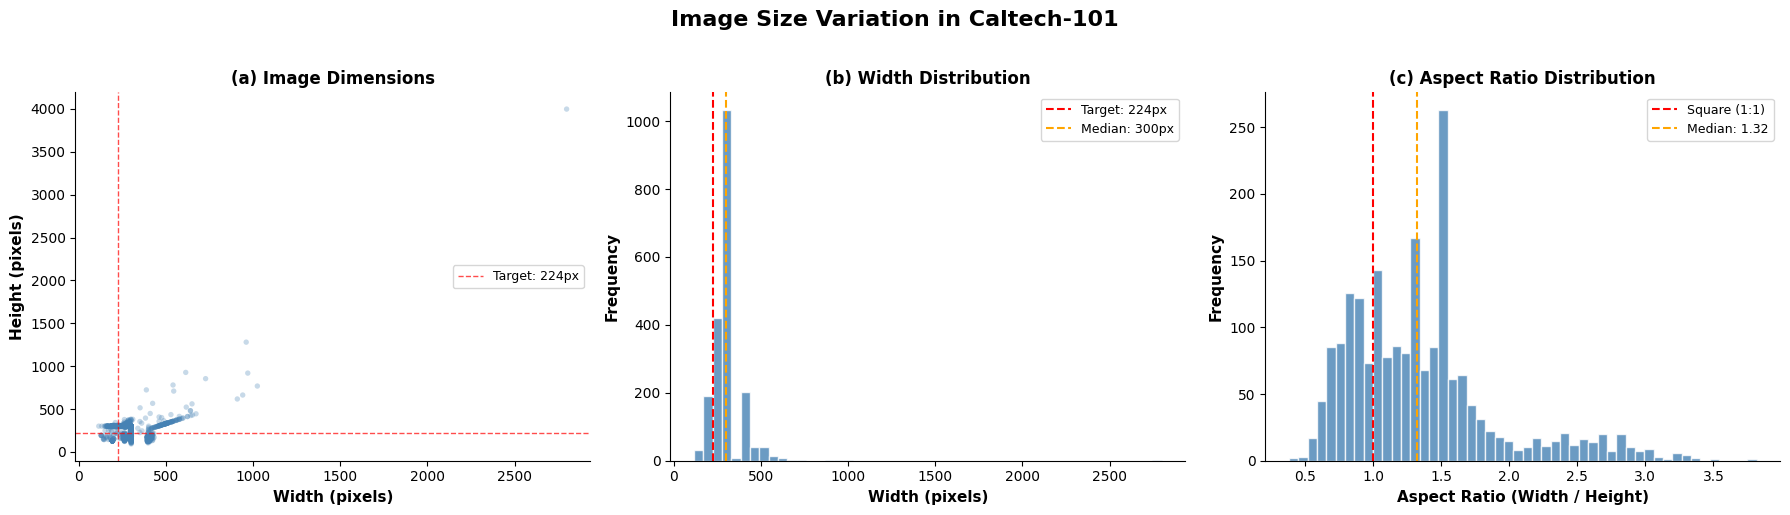


All figures generated successfully!
  - caltech101_sample_images.png       (Figure 3.3)
  - caltech101_class_distribution.png   (Figure 3.4)
  - caltech101_image_size_variation.png (Figure 3.5)


In [1]:
"""
Generate Report Figures for Chapter 3 - Dataset Description
============================================================
Run this script in a Kaggle notebook or Google Colab to generate:
  - Figure 3.3: caltech101_sample_images
  - Figure 3.4: caltech101_class_distribution
  - Figure 3.5: caltech101_image_size_variation

Usage (Kaggle):
  - Add the Caltech-101 dataset to your Kaggle notebook
  - The dataset will be available at /kaggle/input/caltech-101/

Usage (Google Colab):
  - Run: !pip install kagglehub -q
  - The script will auto-download via kagglehub
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import random

# ============================================================
# STEP 1: Load the dataset
# ============================================================

# Try Kaggle path first, then fall back to kagglehub
DATASET_PATH = None

# Option A: Kaggle notebook (dataset added via UI)
kaggle_paths = [
    "/kaggle/input/datasets/imbikramsaha/caltech-101/caltech-101",
    "/kaggle/input/caltech-101/caltech-101/101_ObjectCategories",
    "/kaggle/input/caltech-101/101_ObjectCategories",
]
for p in kaggle_paths:
    if os.path.exists(p):
        # Find the directory with 50+ subdirectories (the actual categories root)
        for root, dirs, files in os.walk(p):
            if len(dirs) > 50:
                DATASET_PATH = root
                break
        if DATASET_PATH:
            break

# Option B: Google Colab (auto-download)
if DATASET_PATH is None:
    try:
        import kagglehub
        base_path = kagglehub.dataset_download("imbikramsaha/caltech-101")
        for root, dirs, files in os.walk(base_path):
            if len(dirs) > 50:
                DATASET_PATH = root
                break
    except ImportError:
        print("ERROR: Could not find dataset. Please either:")
        print("  1. Run on Kaggle with the caltech-101 dataset added, or")
        print("  2. Install kagglehub: pip install kagglehub")
        raise

print(f"Dataset path: {DATASET_PATH}")

# Collect all image paths and labels
image_paths = []
labels = []

classes = sorted([c for c in os.listdir(DATASET_PATH)
                  if os.path.isdir(os.path.join(DATASET_PATH, c))])

print(f"Found {len(classes)} classes")

for class_name in classes:
    class_dir = os.path.join(DATASET_PATH, class_name)
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_name))
            labels.append(class_name)

print(f"Total images: {len(image_paths)}")

# ============================================================
# FIGURE 3.3: Sample Images from Various Categories
# ============================================================
print("\nGenerating Figure 3.3: caltech101_sample_images...")

# Select 15 diverse categories for display (3 rows x 5 cols)
sample_categories = [
    'butterfly', 'airplane', 'car_side', 'faces_easy', 'grand_piano',
    'elephant', 'motorbike', 'sunflower', 'camera', 'dolphin',
    'laptop', 'pagoda', 'flamingo', 'saxophone', 'starfish'
]

# Filter to only categories that exist in the dataset
sample_categories = [c for c in sample_categories if c in classes]

# If not enough, fill with random categories
if len(sample_categories) < 15:
    remaining = [c for c in classes if c not in sample_categories]
    random.seed(42)
    extra = random.sample(remaining, min(15 - len(sample_categories), len(remaining)))
    sample_categories.extend(extra)

# Use exactly 15 (or fewer if dataset has fewer)
sample_categories = sample_categories[:15]
n_cols = 5
n_rows = (len(sample_categories) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
fig.suptitle('Sample Images from Caltech-101 Categories', fontsize=16, fontweight='bold', y=1.02)

for idx, cat in enumerate(sample_categories):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row][col] if n_rows > 1 else axes[col]

    # Find one image from this category
    cat_dir = os.path.join(DATASET_PATH, cat)
    cat_images = [f for f in os.listdir(cat_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if cat_images:
        img_path = os.path.join(cat_dir, cat_images[0])
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
    ax.set_title(cat.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.axis('off')

# Hide any empty subplots
for idx in range(len(sample_categories), n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row][col] if n_rows > 1 else axes[col]
    ax.axis('off')

plt.tight_layout()
plt.savefig('caltech101_sample_images.png', dpi=300, bbox_inches='tight', facecolor='white')
print("  Saved: caltech101_sample_images.png")
plt.show()


# ============================================================
# FIGURE 3.4: Class Distribution Bar Chart
# ============================================================
print("\nGenerating Figure 3.4: caltech101_class_distribution...")

class_counts = Counter(labels)
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
names, counts = zip(*sorted_counts)

fig, ax = plt.subplots(figsize=(22, 7))

# Create color gradient based on count (higher = darker)
max_count = max(counts)
colors = [plt.cm.Blues(0.3 + 0.7 * (c / max_count)) for c in counts]

bars = ax.bar(range(len(names)), counts, color=colors, edgecolor='none', width=0.8)

# Formatting
ax.set_xlabel('Object Category', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('Number of Images', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Caltech-101 Class Distribution (102 Categories)', fontsize=16, fontweight='bold', pad=15)

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=6, ha='center')

# Add horizontal grid lines for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Add annotation for key statistics
ax.annotate(f'Max: {max(counts)} images\n(faces_easy)',
            xy=(0, max(counts)), xytext=(15, max(counts) - 50),
            fontsize=9, fontweight='bold', color='darkblue',
            arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5))

ax.annotate(f'Min: {min(counts)} images',
            xy=(len(names) - 1, min(counts)), xytext=(len(names) - 20, 200),
            fontsize=9, fontweight='bold', color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

# Add mean line
mean_count = np.mean(counts)
ax.axhline(y=mean_count, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Mean: {mean_count:.0f} images/class')
ax.legend(fontsize=10, loc='upper right')

ax.set_xlim(-0.5, len(names) - 0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('caltech101_class_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
print("  Saved: caltech101_class_distribution.png")
plt.show()


# ============================================================
# FIGURE 3.5: Image Size Variation
# ============================================================
print("\nGenerating Figure 3.5: caltech101_image_size_variation...")

# Collect image dimensions (sample for speed)
random.seed(42)
sample_paths = random.sample(image_paths, min(2000, len(image_paths)))

widths = []
heights = []
aspect_ratios = []

for path in sample_paths:
    try:
        img = Image.open(path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)
    except:
        continue

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Image Size Variation in Caltech-101', fontsize=16, fontweight='bold', y=1.02)

# (a) Width vs Height scatter plot
ax1 = axes[0]
scatter = ax1.scatter(widths, heights, alpha=0.3, s=15, c='steelblue', edgecolors='none')
ax1.axhline(y=224, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Target: 224px')
ax1.axvline(x=224, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Height (pixels)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Image Dimensions', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# (b) Width distribution
ax2 = axes[1]
ax2.hist(widths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(x=224, color='red', linestyle='--', linewidth=1.5, label='Target: 224px')
ax2.axvline(x=np.median(widths), color='orange', linestyle='--', linewidth=1.5,
            label=f'Median: {np.median(widths):.0f}px')
ax2.set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('(b) Width Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# (c) Aspect ratio distribution
ax3 = axes[2]
ax3.hist(aspect_ratios, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax3.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Square (1:1)')
ax3.axvline(x=np.median(aspect_ratios), color='orange', linestyle='--', linewidth=1.5,
            label=f'Median: {np.median(aspect_ratios):.2f}')
ax3.set_xlabel('Aspect Ratio (Width / Height)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('(c) Aspect Ratio Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('caltech101_image_size_variation.png', dpi=300, bbox_inches='tight', facecolor='white')
print("  Saved: caltech101_image_size_variation.png")
plt.show()


print("\n" + "=" * 60)
print("All figures generated successfully!")
print("=" * 60)
print("  - caltech101_sample_images.png       (Figure 3.3)")
print("  - caltech101_class_distribution.png   (Figure 3.4)")
print("  - caltech101_image_size_variation.png (Figure 3.5)")
print("=" * 60)
